# Análise Exploratória — Alfabetização nos Municípios Brasileiros

**Tech Challenge Fase 3 — POSTECH AI Scientist**

Este notebook explora a `base_ml_alfabetizacao` construída no
[notebook 01](01_pipeline_medalhao.ipynb): 10.896 linhas (município × ano), rede municipal,
ciclos 2023 e 2024, com 36 preditores legítimos e nenhuma coluna que vaze o alvo.

---

### A EDA não é um passeio pelos dados — ela precisa decidir coisas

Cada seção existe para responder a uma pergunta cuja resposta **muda a modelagem**. Se a
análise não muda nenhuma decisão, ela não deveria estar aqui.

| # | Pergunta | Decisão que depende dela |
|---|---|---|
| 1 | Que forma tem o alvo? | viabilidade do alvo binomial e escolha das métricas |
| 2 | O território explica quanto? Há quebras entre os ciclos? | incluir UF/região; validade do split temporal |
| 3 | Quais blocos de variáveis carregam sinal? | valor real do enriquecimento externo |
| 4 | Há confundimento entre os preditores? | necessidade de controlar por região |
| 5 | Há multicolinearidade? | categorias de referência e regularização |
| 6 | As escalas e as ausências são tratáveis? | composição do `ColumnTransformer` |
| 7 | Os municípios se repetem entre os ciclos? | estratégia de validação cruzada |

Ao final, as seções 8 e 9 consolidam as **hipóteses analíticas** e as **decisões de modelagem**
que elas sustentam.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import carregar_base_ml
from src.visualization import (
    EIXO, GRADE, MUDO, NEGATIVO, POSITIVO, SERIE, SUPERFICIE, TINTA, TINTA_2,
    aplicar_estilo, limpar, num, salvar,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

IMAGENS = RAIZ / "images"
IMAGENS.mkdir(exist_ok=True)

# Paleta, cromo e formatação numérica vêm de src/visualization/estilo.py,
# compartilhados pelos notebooks 02, 03 e 04 — um único lugar para o sistema visual.
aplicar_estilo()

base = carregar_base_ml().drop(columns=["_gold_processed_at"])
print(f"{base.shape[0]} linhas × {base.shape[1]} colunas | "
      f"{base['id_municipio'].nunique()} municípios | anos {sorted(base['ano'].unique())}")

10896 linhas × 38 colunas | 5500 municípios | anos [np.int64(2023), np.int64(2024)]


---

## 1. O alvo — forma, dispersão e extremos

`taxa_alfabetizacao` é o percentual de alunos do 2º ano que atingiram 743 pontos na escala Saeb
de Língua Portuguesa. Antes de qualquer coisa: que forma essa variável tem?

Isso importa por dois motivos concretos. Primeiro, o alvo será convertido em **dado binário
agrupado** (cada município vira duas observações ponderadas, `y=1` com peso `taxa/100` e `y=0`
com peso `1-taxa/100`) — o que exige que a taxa esteja bem distribuída no interior de [0, 100],
e não empilhada nos extremos. Segundo, muita massa em 0% ou 100% causaria problemas de
separação na regressão logística.

In [2]:
resumo = base.groupby("ano")["taxa_alfabetizacao"].describe().round(2)
resumo["assimetria"] = base.groupby("ano")["taxa_alfabetizacao"].skew().round(3)
resumo

,count,mean,std,min,25%,50%,75%,max,assimetria
ano,,,,,,,,,
2023,5448.0,60.28,19.82,4.35,46.50,60.72,75.00,100.0,-0.120
2024,5448.0,62.80,19.34,4.40,48.28,64.05,77.59,100.0,-0.185


In [3]:
alvo = base["taxa_alfabetizacao"]
extremos = pd.DataFrame([
    {"faixa": "taxa = 100% (todos alfabetizados)", "linhas": int((alvo >= 100).sum())},
    {"faixa": "taxa <= 20%", "linhas": int((alvo <= 20).sum())},
    {"faixa": "taxa entre 20% e 100%", "linhas": int(((alvo > 20) & (alvo < 100)).sum())},
])
extremos["% do total"] = (extremos["linhas"] / len(base) * 100).round(1)
extremos

,faixa,linhas,% do total
0,taxa = 100% (todos alfabetizados),121,1.1
1,taxa <= 20%,159,1.5
2,taxa entre 20% e 100%,10616,97.4


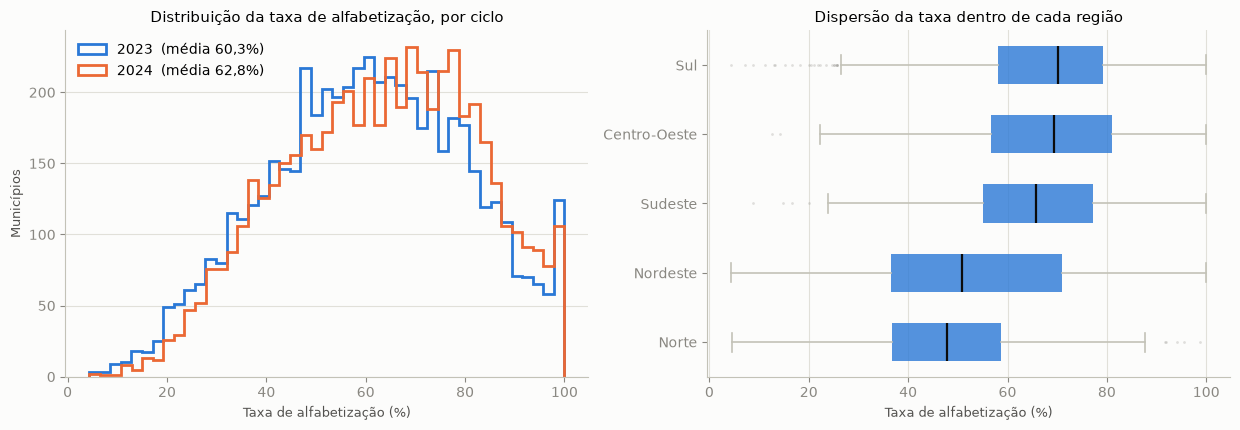

In [4]:
fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.4))

# --- Painel A: distribuição por ciclo (2 séries → legenda) ---
for cor, ano in zip(SERIE, sorted(base["ano"].unique())):
    dados = base.loc[base["ano"] == ano, "taxa_alfabetizacao"]
    eixos[0].hist(dados, bins=45, histtype="step", linewidth=2,
                  color=cor, label=f"{ano}  (média {num(dados.mean(), 1)}%)")
eixos[0].set_title("Distribuição da taxa de alfabetização, por ciclo")
eixos[0].set_xlabel("Taxa de alfabetização (%)")
eixos[0].set_ylabel("Municípios")
eixos[0].legend(loc="upper left")
limpar(eixos[0])

# --- Painel B: dispersão por região (categorias nominais → uma cor só) ---
ordem = base.groupby("regiao")["taxa_alfabetizacao"].median().sort_values().index.tolist()
caixas = eixos[1].boxplot(
    [base.loc[base["regiao"] == r, "taxa_alfabetizacao"].dropna() for r in ordem],
    tick_labels=ordem, orientation="horizontal", widths=0.55, patch_artist=True,
    medianprops=dict(color=TINTA, linewidth=1.6),
    flierprops=dict(marker="o", markersize=2, markerfacecolor=MUDO,
                    markeredgecolor="none", alpha=0.25),
)
for caixa in caixas["boxes"]:
    caixa.set(facecolor=SERIE[0], edgecolor="none", alpha=0.8)
for peca in caixas["whiskers"] + caixas["caps"]:
    peca.set(color=EIXO, linewidth=1.2)
eixos[1].set_title("Dispersão da taxa dentro de cada região")
eixos[1].set_xlabel("Taxa de alfabetização (%)")
limpar(eixos[1], grade="x")

fig.tight_layout()
salvar(fig, "02_distribuicao_alvo", IMAGENS)
plt.show()

**O que isso decide.**

A taxa é **aproximadamente simétrica** (assimetria em torno de −0,15) e ocupa quase toda a faixa
possível, com apenas ~1% das linhas em 100% e ~1,5% abaixo de 20%. Não há empilhamento nos
extremos: o alvo binomial ponderado é viável e a regressão logística não sofrerá de separação
perfeita.

A média subiu de **60,3% para 62,8%** entre os ciclos, mas o painel da direita mostra que **a
média nacional esconde o problema**: a dispersão *dentro* de cada região é enorme — as caixas se
sobrepõem largamente — e as medianas variam muito entre elas. Um modelo que acerte a média e
erre a cauda é inútil para política pública: é o município da cauda inferior que precisa de
intervenção.

**Decisão:** a métrica principal não pode ser acurácia. Como o output é uma probabilidade lida
como "taxa esperada", a avaliação priorizará **AUC-ROC** (capacidade de ordenar municípios por
risco) e **Brier score / curva de calibração** (o valor da probabilidade precisa ser confiável,
não só a ordem).

---

## 2. Geografia e quebras entre os ciclos

A hipótese mais óbvia, e por isso mesmo a primeira a testar: **onde** o município está explica
sua taxa de alfabetização?

In [5]:
por_regiao = (base.pivot_table(index="regiao", columns="ano",
                               values="taxa_alfabetizacao", aggfunc="mean")
                  .round(1).sort_values(2024))
por_regiao["variação"] = (por_regiao[2024] - por_regiao[2023]).round(1)
por_regiao["municípios"] = base[base["ano"] == 2024].groupby("regiao").size()
por_regiao

ano,2023,2024,variação,municípios
regiao,,,,
Norte,45.8,49.4,3.6,435
Nordeste,53.1,56.3,3.2,1780
Sul,72.2,63.8,-8.4,1143
Sudeste,62.2,70.0,7.8,1626
Centro-Oeste,64.5,72.3,7.8,464


A amplitude entre a melhor e a pior região é de **quase 23 pontos percentuais** — maior que o
efeito de qualquer variável isolada que veremos adiante. Mas a coluna `variação` revela algo que
não estava no roteiro: **todas as regiões melhoraram entre 2023 e 2024, exceto o Sul**, que caiu
mais de 8 pontos. Isso precisa ser investigado antes de seguir, porque afeta diretamente a
validade do split temporal.

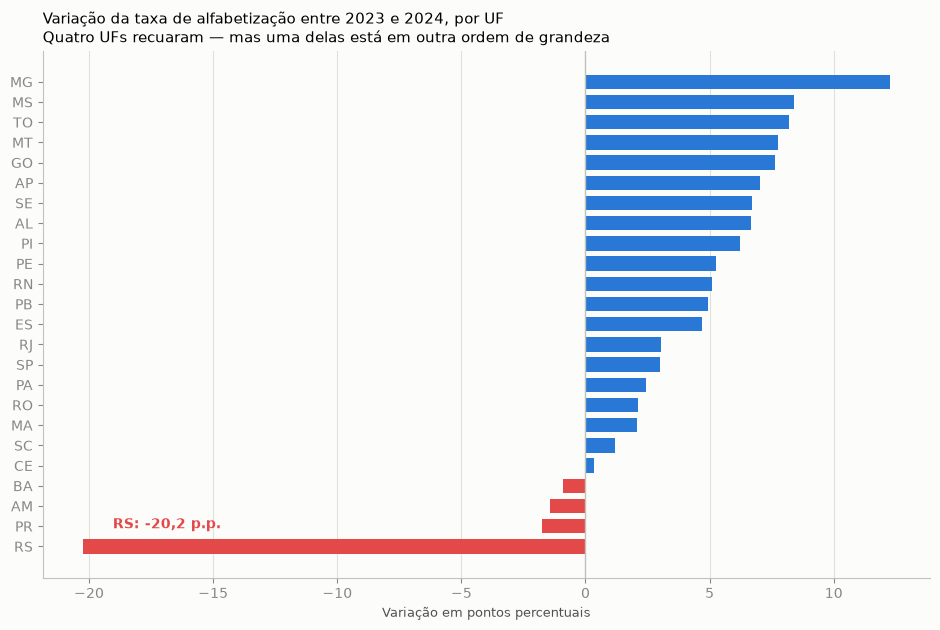

In [6]:
por_uf = base.pivot_table(index="sigla_uf", columns="ano", values="taxa_alfabetizacao")
variacoes = (por_uf[2024] - por_uf[2023]).dropna().sort_values()

fig, eixo = plt.subplots(figsize=(9.5, 6.4))
eixo.barh(variacoes.index, variacoes.values,
          color=[NEGATIVO if v < 0 else POSITIVO for v in variacoes], height=0.72)
eixo.axvline(0, color=EIXO, linewidth=1)

# Rótulo direto apenas no extremo que importa — nunca um número em cada barra.
eixo.annotate(f"{variacoes.index[0]}: {num(variacoes.iloc[0], 1)} p.p.",
              xy=(variacoes.iloc[0] + 1.2, 0.9), color=NEGATIVO,
              fontsize=10, fontweight="bold")

eixo.set_title("Variação da taxa de alfabetização entre 2023 e 2024, por UF\n"
               "Quatro UFs recuaram — mas uma delas está em outra ordem de grandeza", loc="left")
eixo.set_xlabel("Variação em pontos percentuais")
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "02_variacao_por_uf", IMAGENS)
plt.show()

In [7]:
# A queda do RS é generalizada entre seus municípios ou efeito de composição da amostra?
rs = (base[base["sigla_uf"] == "RS"]
      .pivot_table(index="id_municipio", columns="ano", values="taxa_alfabetizacao")
      .dropna())
delta_rs = rs[2024] - rs[2023]

pd.Series({
    "municípios do RS com os dois ciclos": len(rs),
    "queda média (p.p.)": round(delta_rs.mean(), 1),
    "queda mediana (p.p.)": round(delta_rs.median(), 1),
    "% de municípios que caíram": round((delta_rs < 0).mean() * 100, 1),
    "% com queda superior a 20 p.p.": round((delta_rs < -20).mean() * 100, 1),
}, name="Rio Grande do Sul, 2023 → 2024").to_frame()

,"Rio Grande do Sul, 2023 → 2024"
municípios do RS com os dois ciclos,443.0
queda média (p.p.),-20.0
queda mediana (p.p.),-19.9
% de municípios que caíram,89.6
% com queda superior a 20 p.p.,49.4


**A queda é sistêmica, não amostral.** Quase 90% dos municípios gaúchos caíram, com mediana de
−19,9 p.p. e metade deles perdendo mais de 20 pontos. Não é ruído nem mudança na composição da
amostra: é um choque que atingiu o estado inteiro. As outras três UFs negativas (BA, AM, PR)
recuaram menos de 2 pontos — variação normal entre ciclos.

**Hipótese:** as enchentes que atingiram o Rio Grande do Sul entre abril e maio de 2024
interromperam o calendário letivo em grande parte do estado, exatamente na janela do ciclo
avaliativo. É plausível e consistente com o padrão observado, **mas não é comprovável com os
dados desta base**, que não trazem calendário escolar, dias letivos nem ocorrência de desastre.
Fica registrada como hipótese, não como conclusão.

**O que isso decide — a consequência mais importante desta seção.** O plano original era validar
o modelo com um split temporal 2023 → 2024. Um choque exógeno dessa magnitude num estado inteiro
**enfraquece a suposição de que os dois ciclos são comparáveis**: um modelo treinado em 2023
será penalizado em 2024 por um evento que nenhuma variável da base descreve.

O split temporal continua sendo o teste mais honesto de generalização no tempo e será mantido —
mas com duas salvaguardas: (a) as métricas serão reportadas **também excluindo o RS**, para
separar erro de modelo de choque exógeno; (b) a validação principal passa a ser `GroupKFold`
por município, que não depende da comparabilidade entre ciclos.

---

## 3. Correlações com o alvo — o enriquecimento externo valeu a pena?

Esta seção julga a decisão tomada no notebook 01. Removidas as colunas que vazavam o alvo,
sobraram quatro features do INEP original. **Todo o poder preditivo restante precisa vir das
fontes externas** — se elas não trouxerem sinal, o projeto não tem modelo.

Reportamos Pearson e Spearman lado a lado: Pearson mede associação linear; Spearman é monotônica
e robusta a valores extremos, o que importa num alvo limitado a [0, 100].

In [8]:
preditores = base.select_dtypes("number").drop(columns=["taxa_alfabetizacao", "ano"])

correlacoes = pd.DataFrame({
    "pearson": preditores.corrwith(base["taxa_alfabetizacao"]),
    "spearman": preditores.corrwith(base["taxa_alfabetizacao"], method="spearman"),
}).round(3)

BLOCOS = {
    "afd_": "Formação docente (AFD)",
    "atu_": "Tamanho de turma (ATU)",
    "ied_": "Esforço docente (IED)",
    "inse_": "Socioeconômico (INSE)",
    "media_inse": "Socioeconômico (INSE)",
    "qtd_alunos": "Socioeconômico (INSE)",
    "proporcao_rural": "Socioeconômico (INSE)",
}

def bloco(coluna):
    for chave, nome in BLOCOS.items():
        if coluna.startswith(chave):
            return nome
    return "Desempenho pregresso (IDEB 2021)"

correlacoes["bloco"] = [bloco(c) for c in correlacoes.index]
correlacoes.reindex(correlacoes["pearson"].abs().sort_values(ascending=False).index).head(12)

,pearson,spearman,bloco
ideb_2021,0.530,0.519,Desempenho pregresso (IDEB 2021)
nota_matematica_2021,0.516,0.513,Desempenho pregresso (IDEB 2021)
nota_portugues_2021,0.507,0.499,Desempenho pregresso (IDEB 2021)
media_inse,0.298,0.290,Socioeconômico (INSE)
inse_pc_nivel_2,-0.278,-0.289,Socioeconômico (INSE)
inse_pc_nivel_6,0.269,0.268,Socioeconômico (INSE)
inse_pc_nivel_3,-0.264,-0.266,Socioeconômico (INSE)
inse_pc_nivel_5,0.250,0.252,Socioeconômico (INSE)
taxa_aprovacao_2021,0.248,0.263,Desempenho pregresso (IDEB 2021)
inse_pc_nivel_7,0.243,0.256,Socioeconômico (INSE)


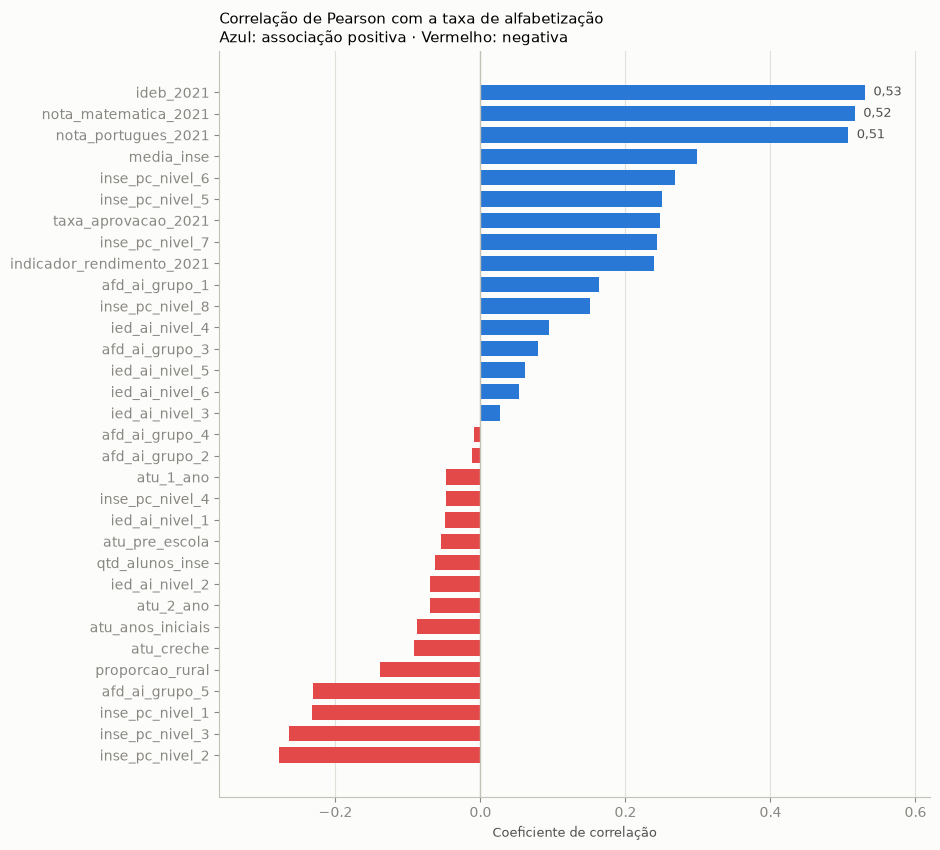

In [9]:
ordenadas = correlacoes.sort_values("pearson")

fig, eixo = plt.subplots(figsize=(9.5, 8.6))
eixo.barh(ordenadas.index, ordenadas["pearson"],
          color=[NEGATIVO if v < 0 else POSITIVO for v in ordenadas["pearson"]], height=0.72)
eixo.axvline(0, color=EIXO, linewidth=1)

# Rótulo direto só nos três extremos — o eixo carrega o resto.
for nome in ordenadas.index[-3:]:
    valor = ordenadas.loc[nome, "pearson"]
    eixo.text(valor + 0.012, nome, num(valor), va="center", fontsize=9, color=TINTA_2)

eixo.set_title("Correlação de Pearson com a taxa de alfabetização\n"
               "Azul: associação positiva · Vermelho: negativa", loc="left")
eixo.set_xlabel("Coeficiente de correlação")
eixo.set_xlim(-0.36, 0.62)
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "02_correlacoes_alvo", IMAGENS)
plt.show()

In [10]:
(correlacoes.assign(forca=correlacoes["pearson"].abs())
            .groupby("bloco")["forca"]
            .agg(variaveis="size", correlacao_maxima="max", correlacao_mediana="median")
            .round(3).sort_values("correlacao_maxima", ascending=False))

,variaveis,correlacao_maxima,correlacao_mediana
bloco,,,
Desempenho pregresso (IDEB 2021),5,0.530,0.507
Socioeconômico (INSE),11,0.298,0.243
Formação docente (AFD),5,0.231,0.080
Esforço docente (IED),6,0.094,0.057
Tamanho de turma (ATU),5,0.091,0.070


**O que isso decide.**

O bloco do **IDEB de 2021 domina**: `ideb_2021` correlaciona **0,53** com o alvo, seguido das
notas de Matemática (0,52) e Português (0,51). É o preditor mais forte da base — e é legítimo,
porque foi publicado dois anos antes do primeiro ciclo do alvo.

O segundo bloco é o **socioeconômico**: `media_inse` chega a 0,30, e os percentuais por nível do
INSE se comportam como se esperaria — os níveis baixos (I a III) correlacionam **negativamente**,
os altos (V a VIII) positivamente. A seção 4 vai mostrar que boa parte desse sinal não é o que
parece.

A **formação docente** aparece na direção teoricamente correta: `afd_ai_grupo_1` (professores com
licenciatura na área) positivo (0,16) e `afd_ai_grupo_5` (sem curso superior) negativo (−0,23),
com sinais opostos e magnitudes semelhantes. Tamanho de turma e esforço docente trazem sinal
fraco (abaixo de 0,10).

**A conclusão que valida o notebook 01:** sem o enriquecimento externo, a correlação máxima
disponível na base seria a de `ano` (0,06). Com ele, chega a 0,53. O enriquecimento não foi um
extra — foi o que tornou o problema modelável.

Nenhuma correlação individual passa de 0,53, o que é saudável: um preditor isolado com 0,95
seria sinal de vazamento, não de qualidade.

---

## 4. Confundimento — o gradiente socioeconômico é, em boa parte, geográfico

`media_inse` correlaciona 0,30 com o alvo. É a segunda maior associação da base, e a tentação é
lê-la como "municípios mais pobres alfabetizam menos". Antes de aceitar isso, vale checar se o
INSE não está medindo, na verdade, **outra coisa**.

In [11]:
com_inse = base.dropna(subset=["media_inse"]).copy()
com_inse["decil_nacional"] = pd.qcut(com_inse["media_inse"], 10, labels=False) + 1

# Composição regional de cada decil nacional de INSE (nº de linhas).
pd.crosstab(com_inse["decil_nacional"], com_inse["regiao"])

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
decil_nacional,,,,,
1,4,822,231,26,0
2,2,924,118,35,3
3,2,915,109,55,2
4,22,745,154,149,11
5,192,162,178,486,64
6,276,4,44,551,208
7,232,0,8,547,299
8,112,0,4,603,358
9,60,0,0,533,489


A tabela já responde: **o decil nacional de INSE é quase um rótulo de região**. Os decis 1 a 3
não têm praticamente nenhum município do Sul (0, 3 e 2 linhas); os decis 7 a 10 não têm
*nenhum* município do Nordeste. Comparar o decil 1 com o decil 10 é, na prática, comparar
Nordeste com Sul.

O teste correto é calcular o decil **dentro de cada região**, de modo que cada faixa tenha
municípios comparáveis entre si.

In [12]:
com_inse["decil_regional"] = (com_inse.groupby("regiao")["media_inse"]
                              .transform(lambda s: pd.qcut(s, 10, labels=False,
                                                           duplicates="drop") + 1))

agregado = com_inse.groupby("decil_nacional")["taxa_alfabetizacao"].mean().round(1)
intrarregional = com_inse.pivot_table(index="decil_regional", columns="regiao",
                                      values="taxa_alfabetizacao").round(1)

# Tabela exibida junto do gráfico: é o dado exato e atende à regra de relevo da
# paleta (três slots claros ficam abaixo de 3:1 contra a superfície).
intrarregional.assign(**{"AGREGADO (decil nacional)": agregado})

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul,AGREGADO (decil nacional)
decil_regional,,,,,,
1,61.2,59.6,43.1,63.6,67.4,56.6
2,65.3,59.8,44.4,66.2,66.1,55.6
3,70.5,59.0,45.6,66.3,69.1,50.4
4,65.7,56.1,41.1,66.7,66.5,52.9
5,65.3,56.3,44.6,67.2,66.4,62.0
6,67.9,51.6,46.1,67.4,67.9,66.5
7,67.8,50.0,46.8,65.2,67.6,68.0
8,72.3,49.1,49.2,66.2,68.1,67.5
9,75.9,49.9,53.7,65.2,68.1,66.5


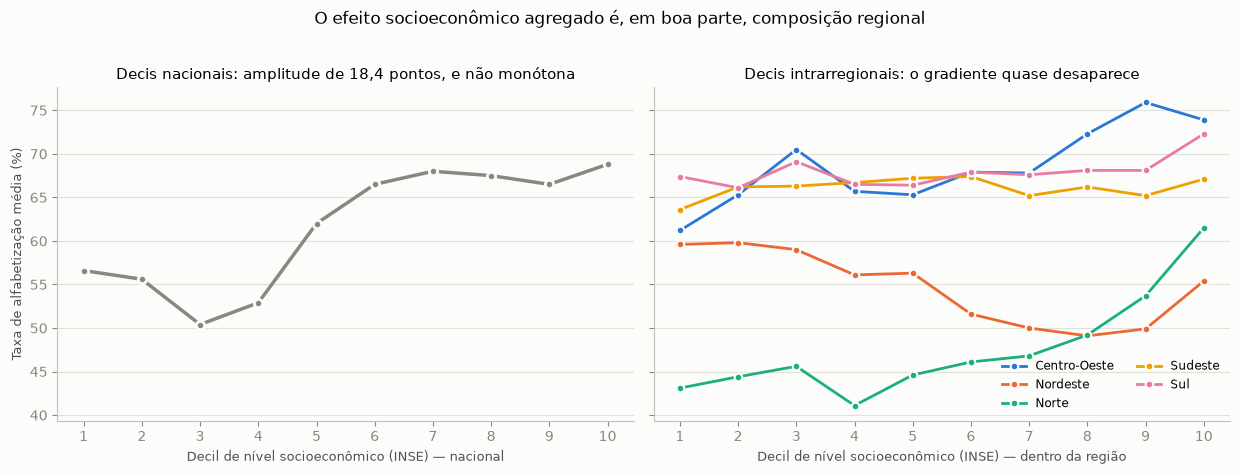

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

# --- Painel A: a relação agregada, com decis nacionais ---
eixos[0].plot(agregado.index, agregado.values, color=MUDO, linewidth=2.5,
              marker="o", markersize=6, markerfacecolor=MUDO,
              markeredgecolor=SUPERFICIE, markeredgewidth=2)
amplitude_agregada = agregado.max() - agregado.min()
eixos[0].set_title(f"Decis nacionais: amplitude de {num(amplitude_agregada, 1)} pontos, e não monótona")
eixos[0].set_xlabel("Decil de nível socioeconômico (INSE) — nacional")
eixos[0].set_ylabel("Taxa de alfabetização média (%)")
eixos[0].set_xticks(range(1, 11))
limpar(eixos[0])

# --- Painel B: decis calculados dentro de cada região ---
for cor, regiao in zip(SERIE, intrarregional.columns):
    serie = intrarregional[regiao].dropna()
    eixos[1].plot(serie.index, serie.values, color=cor, linewidth=2,
                  marker="o", markersize=5.5, markerfacecolor=cor,
                  markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label=regiao)
eixos[1].set_title("Decis intrarregionais: o gradiente quase desaparece")
eixos[1].set_xlabel("Decil de nível socioeconômico (INSE) — dentro da região")
eixos[1].set_xticks(range(1, 11))
eixos[1].legend(loc="lower right", ncol=2, fontsize=8.5)
limpar(eixos[1])

fig.suptitle("O efeito socioeconômico agregado é, em boa parte, composição regional",
             fontsize=12, y=1.02)
fig.tight_layout()
salvar(fig, "02_confundimento_regional", IMAGENS)
plt.show()

In [14]:
# Quantificação: Spearman global contra Spearman dentro de cada região.
spearman_regional = (com_inse.groupby("regiao")
                     .apply(lambda g: pd.Series({
                         "spearman_inse_x_taxa": g["media_inse"].corr(
                             g["taxa_alfabetizacao"], method="spearman"),
                         "linhas": len(g),
                     })).round(3))
spearman_regional.loc["— TODAS AS REGIÕES (agregado) —"] = [
    round(com_inse["media_inse"].corr(com_inse["taxa_alfabetizacao"], method="spearman"), 3),
    len(com_inse),
]
spearman_regional

,spearman_inse_x_taxa,linhas
regiao,,
Centro-Oeste,0.199,910.0
Nordeste,-0.135,3572.0
Norte,0.310,846.0
Sudeste,0.006,3230.0
Sul,0.044,2263.0
— TODAS AS REGIÕES (agregado) —,0.290,10821.0


**O achado.** O gradiente socioeconômico agregado (Spearman **0,29**) **não se sustenta dentro
das regiões**:

| Região | Spearman INSE × taxa | Leitura |
|---|---:|---|
| Norte | **0,31** | gradiente real e forte |
| Centro-Oeste | **0,20** | gradiente moderado |
| Sul | 0,04 | praticamente ausente |
| Sudeste | 0,01 | ausente |
| **Nordeste** | **−0,14** | **invertido** |

Nas duas regiões que concentram 63% das linhas da base (Nordeste e Sudeste), o nível
socioeconômico **não ordena** o desempenho — e no Nordeste ele o ordena ao contrário. Verificamos
se isso era um artefato do Ceará (que tem taxa muito alta com INSE médio): removendo o estado, a
correlação do Nordeste continua negativa (−0,11). Não é um caso isolado.

Este é um **paradoxo de Simpson** de manual: a associação agregada existe porque os decis de INSE
são, na prática, rótulos de região, e as regiões diferem em muitas outras coisas além de renda.

**O que isso decide.**

1. `sigla_uf` e `regiao` entram no modelo como categóricas (one-hot). Não são controles
   cosméticos — sem elas, o coeficiente de `media_inse` seria estimado com viés, e a
   interpretação em *odds ratio* que justifica a escolha da Regressão Logística ficaria errada.
2. **Expectativa registrada antes de treinar:** o coeficiente de `media_inse` no modelo completo
   deve ser **bem menor** do que a correlação bruta de 0,30 sugere. Se vier grande, é sinal de que
   o controle regional falhou.
3. Uma advertência para a narrativa executiva: **não** apresentar "o nível socioeconômico
   determina a alfabetização". O dado não sustenta isso.

In [15]:
# O contraexemplo mais eloquente da base: mesmo INSE, resultados opostos.
(base[base["regiao"] == "Nordeste"]
 .groupby("sigla_uf")
 .agg(taxa_media=("taxa_alfabetizacao", "mean"),
      inse_medio=("media_inse", "mean"),
      municipios=("id_municipio", "nunique"))
 .round(2).sort_values("taxa_media", ascending=False))

,taxa_media,inse_medio,municipios
sigla_uf,,,
CE,90.14,4.37,184
PE,62.96,4.37,184
PI,62.88,4.31,224
MA,62.25,4.29,217
PB,56.87,4.44,223
AL,49.31,4.34,102
RN,39.11,4.52,167
BA,37.06,4.47,417
SE,33.09,4.40,75


**Ceará e Pernambuco têm INSE praticamente idêntico (4,37) e taxas de 90,1% contra 63,0%** — 27
pontos percentuais que o nível socioeconômico não explica. E o Ceará supera todas as UFs do
Sudeste e do Sul com um INSE muito inferior ao delas.

O Ceará é o estado com a política de alfabetização mais antiga e consolidada do país (o PAIC,
iniciado em 2007, serviu de referência para o desenho do Compromisso Nacional Criança
Alfabetizada). O dado é consistente com a leitura de que **gestão e política pública podem
superar a condição socioeconômica** — que é, afinal, a tese que dá sentido ao projeto: se o
resultado fosse determinado pela renda, não haveria o que recomendar a um gestor.

Há um limite honesto a declarar: a base **não contém nenhuma variável de política educacional**
(formação continuada, material estruturado, regime de colaboração). O efeito do Ceará será
absorvido pela dummy de UF, sem que o modelo saiba *por quê*. Isso vai para as limitações e para
as evoluções futuras.

---

## 5. Multicolinearidade — dois problemas de naturezas diferentes

Regressão Logística é sensível a preditores redundantes: coeficientes ficam instáveis e a
interpretação em *odds ratio*, que é o motivo pelo qual escolhemos o algoritmo, perde sentido.
A base tem duas fontes de redundância, e cada uma pede um tratamento diferente.

In [16]:
composicionais = {
    "AFD — formação docente": [f"afd_ai_grupo_{i}" for i in range(1, 6)],
    "IED — esforço docente": [f"ied_ai_nivel_{i}" for i in range(1, 7)],
    "INSE — níveis socioeconômicos": [f"inse_pc_nivel_{i}" for i in range(1, 9)],
}

pd.DataFrame([
    {"bloco": nome, "variáveis": len(colunas),
     "soma média": round(base[colunas].sum(axis=1).mean(), 2),
     "% de linhas somando ~100":
         round(base[colunas].sum(axis=1).between(99.5, 100.5).mean() * 100, 1)}
    for nome, colunas in composicionais.items()
])

,bloco,variáveis,soma média,% de linhas somando ~100
0,AFD — formação docente,5,99.94,99.9
1,IED — esforço docente,6,100.00,100.0
2,INSE — níveis socioeconômicos,8,99.31,99.3


**Problema 1 — blocos composicionais.** AFD, IED e INSE são **percentuais que somam 100%** por
construção. Isso cria **colinearidade perfeita**: a última categoria de cada bloco é
`100 − (soma das demais)`, informação zero. É a mesma armadilha da *dummy variable trap*, só que
com variáveis contínuas.

**Decisão:** descartar uma **categoria de referência** por bloco, escolhida pela interpretação —
`afd_ai_grupo_5` (docentes sem curso superior), `ied_ai_nivel_1` (menor esforço) e
`inse_pc_nivel_1` (nível socioeconômico mais baixo). Cada coeficiente passa a ser lido como
"efeito de deslocar um ponto percentual **da categoria de referência** para esta".

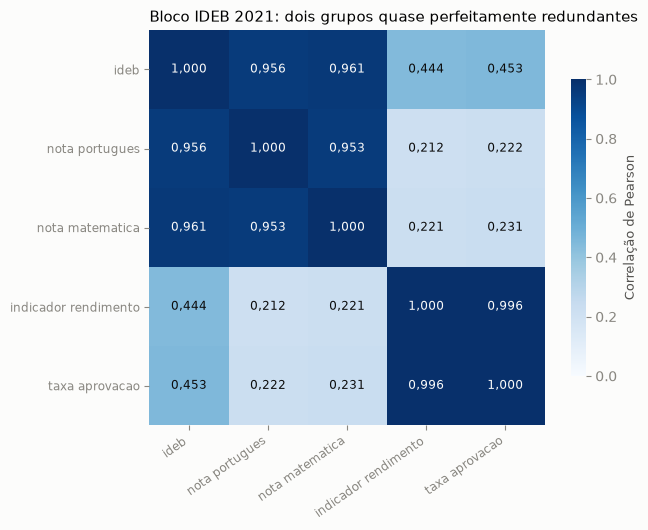

In [17]:
bloco_ideb = ["ideb_2021", "nota_portugues_2021", "nota_matematica_2021",
              "indicador_rendimento_2021", "taxa_aprovacao_2021"]
matriz = base[bloco_ideb].corr()

fig, eixo = plt.subplots(figsize=(6.8, 5.4))
# Todas as correlações do bloco são positivas → escala sequencial de um só matiz,
# não divergente (não há polaridade a representar).
imagem = eixo.imshow(matriz, cmap="Blues", vmin=0, vmax=1)

rotulos = [c.replace("_2021", "").replace("_", " ") for c in bloco_ideb]
eixo.set_xticks(range(len(rotulos)), rotulos, rotation=35, ha="right", fontsize=8.5)
eixo.set_yticks(range(len(rotulos)), rotulos, fontsize=8.5)
for i in range(len(bloco_ideb)):
    for j in range(len(bloco_ideb)):
        valor = matriz.iloc[i, j]
        eixo.text(j, i, num(valor, 3), ha="center", va="center", fontsize=8.5,
                  color=SUPERFICIE if valor > 0.6 else TINTA)

eixo.set_title("Bloco IDEB 2021: dois grupos quase perfeitamente redundantes", loc="left")
eixo.grid(False)
eixo.spines[:].set_visible(False)
barra = fig.colorbar(imagem, ax=eixo, shrink=0.75)
barra.outline.set_visible(False)
barra.set_label("Correlação de Pearson", fontsize=9, color=TINTA_2)
fig.tight_layout()
salvar(fig, "02_multicolinearidade_ideb", IMAGENS)
plt.show()

**Problema 2 — redundância dentro do bloco IDEB.** O heatmap mostra dois agrupamentos quase
perfeitos:

- `ideb_2021`, `nota_portugues_2021` e `nota_matematica_2021` correlacionam entre si **0,953 a
  0,961** — o IDEB é, por definição, uma composição das notas com o indicador de rendimento;
- `indicador_rendimento_2021` e `taxa_aprovacao_2021` correlacionam **0,996** — são
  essencialmente a mesma variável em escalas diferentes.

**Decisão:** manter `ideb_2021` (o índice composto, o mais interpretável para um gestor) e
`taxa_aprovacao_2021` (que carrega a dimensão de fluxo escolar, distinta da proficiência),
descartando as duas notas e o indicador de rendimento. Como salvaguarda adicional, a Regressão
Logística usará **regularização L2**, que estabiliza coeficientes na presença de colinearidade
residual.

---

## 6. Escalas e ausências

Duas verificações rápidas que determinam a composição do `ColumnTransformer`.

In [18]:
escalas = (base.select_dtypes("number")
               .drop(columns=["taxa_alfabetizacao", "ano"])
               .agg(["min", "max", "std"]).T.round(2)
               .sort_values("std", ascending=False))
pd.concat([escalas.head(4), escalas.tail(3)])

,min,max,std
qtd_alunos_inse,3.00,80160.00,1841.28
nota_matematica_2021,143.21,326.04,21.86
ied_ai_nivel_1,0.00,100.00,21.14
nota_portugues_2021,135.36,296.89,20.83
media_inse,3.35,6.28,0.46
proporcao_rural,0.00,1.00,0.23
indicador_rendimento_2021,0.68,1.00,0.04


As escalas são **incomparáveis**: `qtd_alunos_inse` vai de 3 a 80.160 (desvio ~1.841), enquanto
`media_inse` vive entre 4 e 6 (desvio ~0,3). Numa regressão logística regularizada isso não é
detalhe estético: a penalidade L2 encolhe coeficientes proporcionalmente à escala da variável, de
modo que, sem padronizar, a regularização puniria arbitrariamente as variáveis de escala pequena.

**Decisão:** `StandardScaler` em todas as numéricas, dentro do `ColumnTransformer` — portanto
**ajustado apenas no fold de treino**. Padronizar antes do split usaria a média e o desvio do
conjunto de teste, que é vazamento de estatística.

In [19]:
ausentes = (base.isna().mean() * 100).round(1)
ausentes[ausentes > 0].sort_values(ascending=False).rename("% ausente").to_frame()

,% ausente
ideb_2021,13.3
nota_matematica_2021,13.3
nota_portugues_2021,13.3
indicador_rendimento_2021,5.0
taxa_aprovacao_2021,5.0
atu_creche,1.6
media_inse,0.7
inse_pc_nivel_6,0.7
inse_pc_nivel_5,0.7
inse_pc_nivel_4,0.7


As ausências têm naturezas distintas, e por isso tratamentos distintos:

- **IDEB (13,3%)** — o município não teve IDEB divulgado no ciclo. São tipicamente municípios
  pequenos e isolados: a **ausência é informativa**. Imputação pela mediana **com
  `add_indicator=True`**, para que o modelo possa usar o próprio fato da ausência como sinal.
- **`atu_creche` (1,6%)** — município sem oferta de creche. Imputação pela mediana.
- **INSE (0,7%) e AFD (0,1%)** — ausência residual, sem padrão aparente. Imputação pela mediana.

Toda imputação vive **dentro do `Pipeline`**, ajustada por fold. Imputar sobre a base inteira
antes da validação usaria informação do conjunto de teste para preencher o de treino.

---

## 7. Persistência temporal — como validar sem enganar a si mesmo

A base tem cada município repetido em dois ciclos. Se o mesmo município puder aparecer no treino
e na validação, o modelo pode simplesmente **memorizá-lo** — e a métrica ficaria ótima sem
nenhuma capacidade real de generalizar para municípios novos.

O tamanho desse risco é medido pela correlação entre a taxa do mesmo município nos dois ciclos.

In [20]:
painel = base.pivot_table(index="id_municipio", columns="ano", values="taxa_alfabetizacao")
pareados = painel.dropna()
contagem = base.groupby("id_municipio")["ano"].nunique()

pd.Series({
    "municípios distintos na base": len(contagem),
    "presentes nos dois ciclos": int((contagem == 2).sum()),
    "presentes em apenas um ciclo": int((contagem == 1).sum()),
    "correlação da taxa 2023 × 2024 (mesmo município)":
        round(pareados[2023].corr(pareados[2024]), 3),
}, name="painel").to_frame()

,painel
municípios distintos na base,5500.000
presentes nos dois ciclos,5396.000
presentes em apenas um ciclo,104.000
correlação da taxa 2023 × 2024 (mesmo município),0.636


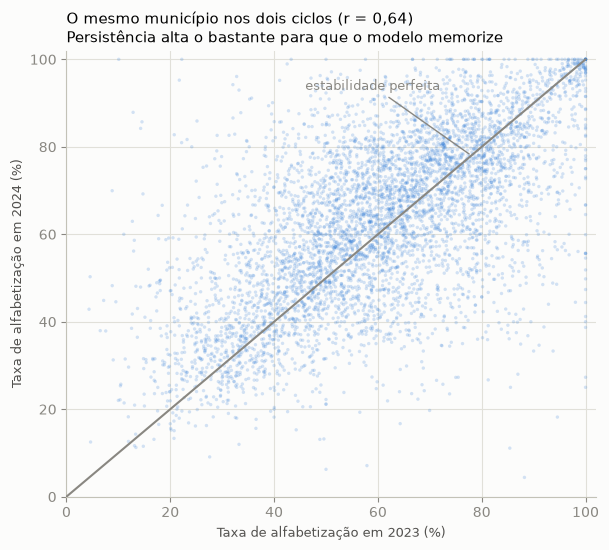

In [21]:
fig, eixo = plt.subplots(figsize=(6.2, 5.6))
eixo.scatter(pareados[2023], pareados[2024], s=6, alpha=0.2,
             color=SERIE[0], edgecolors="none")
eixo.plot([0, 100], [0, 100], color=MUDO, linewidth=1.5, zorder=3)
eixo.annotate("estabilidade perfeita", xy=(78, 78), xytext=(46, 93), color=MUDO, fontsize=9,
              arrowprops=dict(arrowstyle="-", color=MUDO, linewidth=1))

correlacao = pareados[2023].corr(pareados[2024])
eixo.set_title(f"O mesmo município nos dois ciclos (r = {num(correlacao)})\n"
               "Persistência alta o bastante para que o modelo memorize", loc="left")
eixo.set_xlabel("Taxa de alfabetização em 2023 (%)")
eixo.set_ylabel("Taxa de alfabetização em 2024 (%)")
eixo.set_xlim(0, 102)
eixo.set_ylim(0, 102)
limpar(eixo)
eixo.grid(axis="x", color=GRADE, linewidth=0.8)
fig.tight_layout()
salvar(fig, "02_persistencia_temporal", IMAGENS)
plt.show()

**Duas conclusões.**

A correlação de **0,64** confirma o risco: o município é uma unidade persistente, e deixá-lo
atravessar a fronteira entre treino e validação inflaria a métrica artificialmente.

E uma descoberta que **corrige uma imprecisão do notebook 01**: o painel não é perfeitamente
balanceado. Há 5.448 linhas em cada ciclo, mas **5.500 municípios distintos** — apenas 5.396
aparecem nos dois. Os 104 restantes entram ou saem entre os ciclos (notavelmente, os municípios
do Acre só aparecem em 2024). O *número* de linhas por ano é idêntico; o *conjunto* de
municípios, não. Isso não invalida o split temporal, mas obriga a reportar as métricas sobre a
interseção quando a comparação precisar ser pareada.

**Decisão de validação (consolidando também a seção 2):**

1. **`GroupKFold` por `id_municipio`** como validação principal — nenhum município em dois folds;
2. **split temporal 2023 → 2024** como teste de generalização no tempo, com métricas reportadas
   *com* e *sem* o Rio Grande do Sul, para separar erro de modelo de choque exógeno;
3. `random_state` fixo e pipeline inteira serializável, para replicabilidade.

---

## 8. Hipóteses analíticas

A EDA sustenta cinco hipóteses, que o modelo do notebook 03 vai testar:

| # | Hipótese | Evidência na EDA | Como será testada |
|---|---|---|---|
| **H1** | O desempenho pregresso do município é o melhor preditor disponível da alfabetização atual | IDEB 2021 tem a maior correlação da base (0,53), acima de qualquer variável contemporânea | magnitude e significância do coeficiente de `ideb_2021` |
| **H2** | O efeito socioeconômico é **muito menor** do que a correlação bruta sugere — boa parte dele é geografia | dentro das regiões, Spearman cai de 0,29 para 0,01 (Sudeste), 0,04 (Sul) e −0,14 (Nordeste) | comparar o coeficiente de `media_inse` com e sem as dummies de UF |
| **H3** | A qualificação docente tem efeito próprio, independente do contexto socioeconômico | `afd_ai_grupo_1` (+0,16) e `afd_ai_grupo_5` (−0,23) têm sinais opostos e magnitude semelhante | sinal e significância dos coeficientes do bloco AFD no modelo completo |
| **H4** | Há um efeito de gestão estadual que as variáveis observáveis não capturam | Ceará e Pernambuco: mesmo INSE (4,37), 27 p.p. de diferença | magnitude dos coeficientes das dummies de UF depois de controlar tudo o mais |
| **H5** | Municípios rurais e de pequeno porte enfrentam desvantagem estrutural | `proporcao_rural` correlaciona −0,14; a ausência de IDEB se concentra em municípios pequenos | coeficiente de `proporcao_rural` e do indicador de ausência do IDEB |

---

## 9. Decisões de modelagem que esta EDA fixou

| Decisão | Seção |
|---|---|
| Alvo binomial ponderado é viável — não há massa nos extremos | 1 |
| Métricas: AUC-ROC + Brier/calibração, não acurácia | 1 |
| `sigla_uf` e `regiao` como categóricas (one-hot) — controle obrigatório, não cosmético | 4 |
| Descartar uma categoria de referência em cada bloco composicional (AFD, IED, INSE) | 5 |
| Do bloco IDEB, manter `ideb_2021` e `taxa_aprovacao_2021`; descartar as notas e o rendimento | 5 |
| Regularização L2 para estabilizar coeficientes | 5 |
| `StandardScaler` em todas as numéricas, ajustado por fold | 6 |
| Imputação pela mediana, com `add_indicator=True` no bloco IDEB | 6 |
| Validação: `GroupKFold` por município + split temporal 2023 → 2024 | 2, 7 |
| Métricas do split temporal reportadas com e sem o RS | 2 |

**Próximo passo:** `03_modelagem.ipynb` — construção do alvo binomial ponderado, `Pipeline` do
Scikit-learn com o pré-processamento integrado, treinamento da Regressão Logística, otimização
de hiperparâmetros e interpretação dos coeficientes em *odds ratio*.